In [1]:
#import

import torch 
import numpy as np

alpha = drwas samples form a beta distribution 



In [2]:



def mixup_data(x, y, alpha=1):

    mixup_coeff = np.random.beta(alpha, alpha) if alpha>0 else 1
    index = torch.randperm(x.size()[0]).to(x.device)

    mixed_x = mixup_coeff * x + (1 - mixup_coeff) * x[index, :]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, mixup_coeff

lam: 0.49187238780439957
Mixed WMH image: tensor([[[[-2.4993, -2.4993, -2.4993,  ..., -2.4993, -2.4993, -2.4993],
          [-2.4993, -2.4993, -2.4993,  ..., -2.4993, -2.4993, -2.4993],
          [-2.4993, -2.4993, -2.4993,  ..., -2.4993, -2.4993, -2.4993],
          ...,
          [-2.4993, -2.4993, -2.4993,  ..., -2.4993, -2.4993, -2.4993],
          [-2.4993, -2.4993, -2.4993,  ..., -2.4993, -2.4993, -2.4993],
          [-2.4993, -2.4993, -2.4993,  ..., -2.4993, -2.4993, -2.4993]],

         [[-2.4993, -2.4993, -2.4993,  ..., -2.4993, -2.4993, -2.4993],
          [-2.4993, -2.4993, -2.4993,  ..., -2.4993, -2.4993, -2.4993],
          [-2.4993, -2.4993, -2.4993,  ..., -2.4993, -2.4993, -2.4993],
          ...,
          [-2.4993, -2.4993, -2.4993,  ..., -2.4993, -2.4993, -2.4993],
          [-2.4993, -2.4993, -2.4993,  ..., -2.4993, -2.4993, -2.4993],
          [-2.4993, -2.4993, -2.4993,  ..., -2.4993, -2.4993, -2.4993]],

         [[-2.4993, -2.4993, -2.4993,  ..., -2.4993, -2.4993

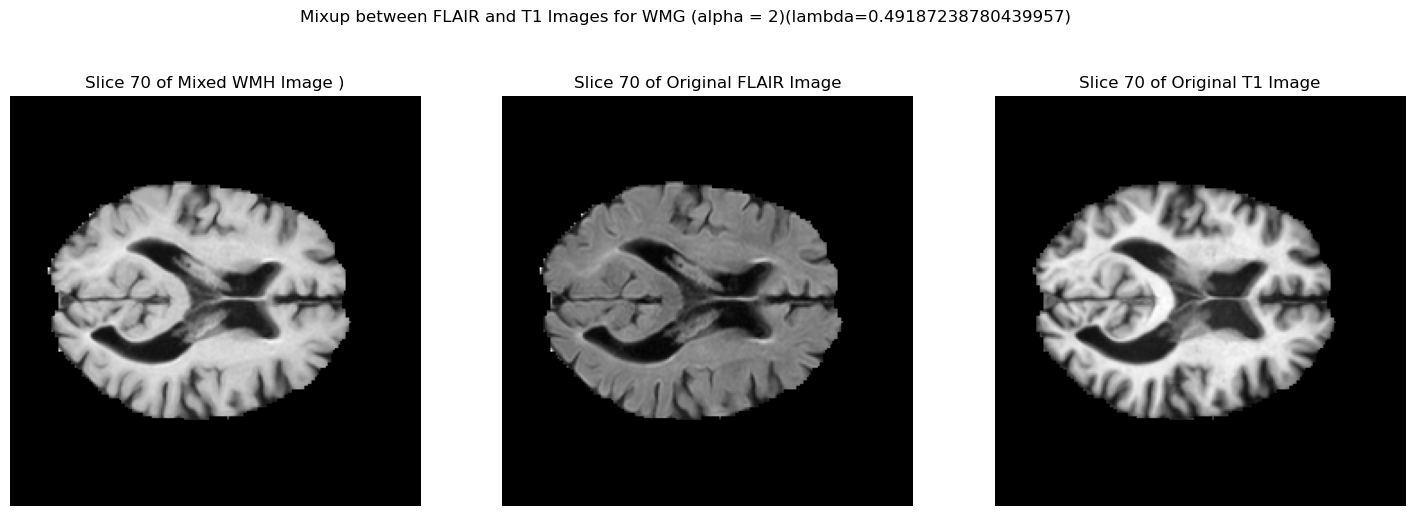

In [23]:
import nibabel as nib
import torch
import numpy as np

# original implementation mixup





def mixup_data(x:torch.tensor, alpha=2):
    """Returns mixed inputs, pairs of targets, and lambda"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
        print("lam:", lam)
    else:
        lam = 1
        # if lam is 1 then mixed image same as one of the images and if 
        # 0 then its the same as other image,
        # do not want this so set a range e.g. between 0.2 and 0.8 for example. 

    batch_size = x.size()[0]
    index = torch.randperm(batch_size)
    mixed_x = lam * x[index[0]] + (1 - lam) * x[index[1]]
    mixed_x = mixed_x.unsqueeze(0)
    return mixed_x, lam






# Load a NIfTI image from the WMH dataset

# Assuming the path to the NIfTI file is 'wmh_image.nii.gz'
wmh_image_path = 'data/WMH/Images/train_23_u.nii.gz'
wmh_image_nifti = nib.load(wmh_image_path)
wmh_image_data = wmh_image_nifti.get_fdata()

# Convert the NIfTI image data to a tensor
wmh_image_tensor = torch.tensor(
    wmh_image_data, dtype=torch.float32
)  # Add batch dimension
wmh_image_tensor1 = wmh_image_tensor.permute(
    3, 0, 1, 2
)  # Change the order of dimensions to (C, H, W, D)
wmh_flair = wmh_image_tensor1[0].unsqueeze(0)
wmh_t1 = wmh_image_tensor1[1].unsqueeze(0)

wmh_image_tensor_1= wmh_image_tensor1[[0,1],:,:,:]

# Mixup between the two channels
mixed_wmh_image, lam = mixup_data(wmh_image_tensor_1, alpha=2)

print("Mixed WMH image:", mixed_wmh_image)

alpha = 2

# label

label_path = "data/WMH/Labels/train_0_u.nii.gz"
label_nifti = nib.load(label_path)
label_data = label_nifti.get_fdata()


#Apply mixup to FLAIR and T1 modalities

# PRINT MIXED IMAGE

import matplotlib.pyplot as plt

# Select a slice to visualize
slice_index = 70

# Create a subplot for all three images
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# plot title of the subplot
fig.suptitle(f"Mixup between FLAIR and T1 Images for WMG (alpha = {alpha})(lambda={lam})")

# Plot the slice of the mixed image




axes[0].imshow(mixed_wmh_image[0, :, :, slice_index].cpu().numpy(), cmap="gray")
axes[0].set_title(f"Slice {slice_index} of Mixed WMH Image )")
axes[0].axis("off")


# Plot the slice of the original FLAIR image
axes[1].imshow(wmh_flair[0, :, :, slice_index].cpu().numpy(), cmap="gray")
axes[1].set_title(f"Slice {slice_index} of Original FLAIR Image")
axes[1].axis("off")

# Plot the slice of the original T1 image
axes[2].imshow(wmh_t1[0, :, :, slice_index].cpu().numpy(), cmap="gray")
axes[2].set_title(f"Slice {slice_index} of Original T1 Image")
axes[2].axis("off")

plt.show()





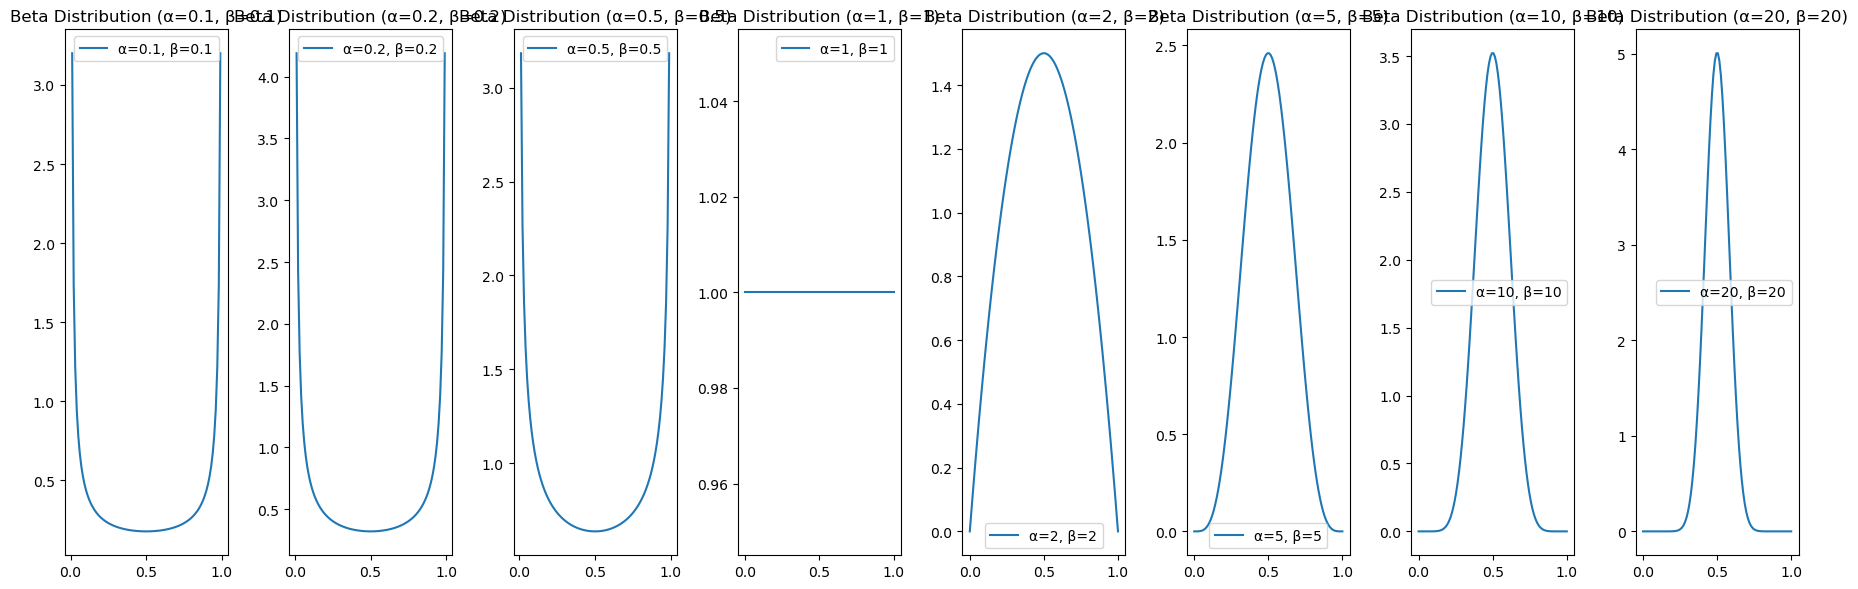

In [21]:
# Plot different beta distributions for various alpha and beta values
import matplotlib.pyplot as plt
from scipy.stats import beta

# Define alpha and beta values
alpha_values = [0.1,0.2,0.5, 1, 2, 5,10,20]

# Create a range of x values from 0 to 1
x = np.linspace(0, 1, 100)

# Create a subplot for each alpha value (since alpha and beta are the same)
fig, axes = plt.subplots(1, len(alpha_values), figsize=(18, 6))

for i, alpha in enumerate(alpha_values):
    y = beta.pdf(x, alpha,alpha)
    axes[i].plot(x, y, label=f'α={alpha}, β={alpha}')
    axes[i].set_title(f'Beta Distribution (α={alpha}, β={alpha})')
    axes[i].legend()

plt.tight_layout()
plt.show()
